# M1-B1 — Réentraînement Pyrenex Crédit (template)

> Duplique ce notebook en `M1-B1_<prenom>_scoring.ipynb` et travaille dessus.

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

RANDOM_STATE = 42
# Sur Google Colab, le répertoire de stockage de session par défaut est /content
DATA_DIR = Path('/content/data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

# Chargement du modèle de 2017 (on remonte de 'notebooks' vers la racine, puis vers la baseline)
# Adapte le chemin si ton dossier pyrenex-risk-v1 est nommé différemment

In [5]:
import warnings
import joblib

# Masquer spécifiquement les warnings de scikit-learn/pickle
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Chargement du modèle de 2017
baseline_bundle = joblib.load("/content/pyrenex-risk-v1/Models/pyrenex_risk_v1.joblib")

print("=== SCHÉMA DE LA BASELINE 2017 ===")
print("Variables numériques :", baseline_bundle["numeric_features"])
print("Variables catégorielles :", baseline_bundle["categorical_features"])
print("\nConfiguration de l'algorithme :", baseline_bundle["model"])

=== SCHÉMA DE LA BASELINE 2017 ===
Variables numériques : ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util']
Variables catégorielles : ['term', 'grade', 'home_ownership', 'verification_status', 'purpose', 'emp_length']

Configuration de l'algorithme : RandomForestClassifier(n_jobs=-1, random_state=2017)


## 2. EDA du nouveau dataset

Au moins 3 visualisations + un paragraphe sur ce qui diffère du dataset 2017.

/tmp/ipykernel_3442/981353306.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_status', palette="viridis")


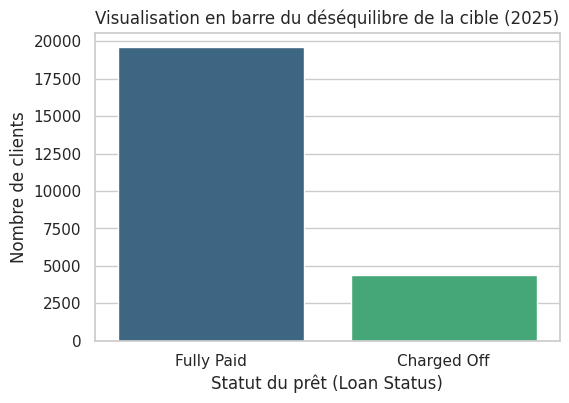

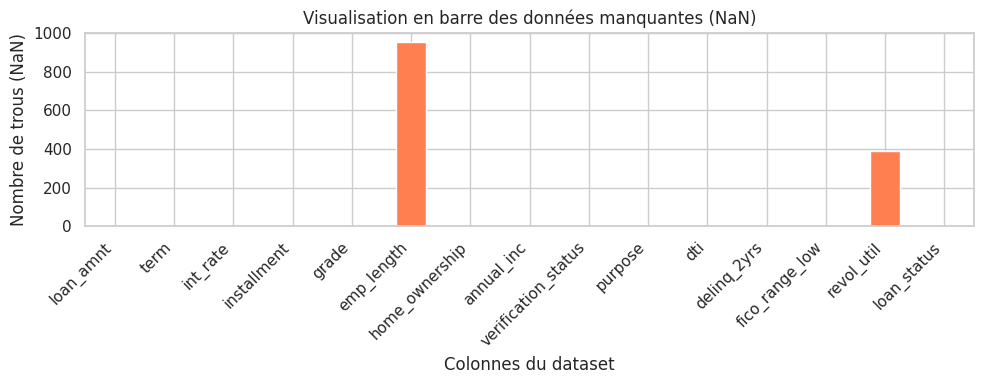

In [6]:
df = pd.read_csv(DATA_DIR / 'lending_club_train.csv')
df.shape, df.head(3)
import matplotlib.pyplot as plt
import seaborn as sns

# On s'assure que le style est propre
sns.set_theme(style="whitegrid")

# Graphique 1 : Le déséquilibre de la variable cible (Prêt remboursé vs Défaut)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', palette="viridis")
plt.title("Visualisation en barre du déséquilibre de la cible (2025)")
plt.xlabel("Statut du prêt (Loan Status)")
plt.ylabel("Nombre de clients")
plt.show()

# Graphique 2 : Le compte des valeurs manquantes (NaN) par colonne
plt.figure(figsize=(10, 4))
df.isna().sum().plot(kind='bar', color='coral')
plt.title("Visualisation en barre des données manquantes (NaN)")
plt.xlabel("Colonnes du dataset")
plt.ylabel("Nombre de trous (NaN)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Préparation et split

Split stratifié, `random_state=42`.

In [7]:
from sklearn.model_selection import train_test_split

# 1. On sépare les caractéristiques (X) de la cible à deviner (y)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# 2. On effectue le split stratifié (80% Train / 20% Validation)
# Le paramètre random_state=42 garantit que tu auras le même découpage à chaque exécution
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. On affiche les résultats pour vérifier que tout est conforme
print("=== STATISTIQUES DU DÉCOUPAGE ===")
print(f"Lignes d'entraînement (X_train) : {X_train.shape[0]}")
print(f"Lignes de validation (X_val) : {X_val.shape[0]}")
print("\n--- Proportion de la cible dans le bloc d'Entraînement ---")
print(y_train.value_counts(normalize=True))
print("\n--- Proportion de la cible dans le bloc de Validation ---")
print(y_val.value_counts(normalize=True))

=== STATISTIQUES DU DÉCOUPAGE ===
Lignes d'entraînement (X_train) : 19200
Lignes de validation (X_val) : 4800

--- Proportion de la cible dans le bloc d'Entraînement ---
loan_status
Fully Paid     0.816146
Charged Off    0.183854
Name: proportion, dtype: float64

--- Proportion de la cible dans le bloc de Validation ---
loan_status
Fully Paid     0.816042
Charged Off    0.183958
Name: proportion, dtype: float64


## 4. Entraînement + benchmark

Au moins 2 jeux d'hyperparamètres. Trace chaque run dans `../experiments.md`.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# 1. On récupère la liste exacte des colonnes de la baseline
num_cols = baseline_bundle["numeric_features"]
cat_cols = baseline_bundle["categorical_features"]

# 2. Chaîne de traitement pour les nombres (gère les NaN de revol_util)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Chaîne de traitement pour les textes (gère les NaN de emp_length)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Assemblage du préprocesseur global
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# =====================================================================
# JEU A : Configuration "Aveugle" (Identique à 2017, sans class_weight)
# =====================================================================
pipeline_A = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])
pipeline_A.fit(X_train, y_train)

# =====================================================================
# JEU B : Configuration "Balanced" (correction du déséquilibre)
# =====================================================================
pipeline_B = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])
pipeline_B.fit(X_train, y_train)

print("🎉 Modèles A et B entraînés avec succès !")

🎉 Modèles A et B entraînés avec succès !


In [10]:
# Prédictions sur le jeu de validation interne
pred_A = pipeline_A.predict(X_val)
pred_B = pipeline_B.predict(X_val)

print("==========================================")
print(f"🏆 SCORE F1 MACRO JEU A (2017) : {f1_score(y_val, pred_A, average='macro'):.4f}")
print(f"🏆 SCORE F1 MACRO JEU B (CORRIGÉ) : {f1_score(y_val, pred_B, average='macro'):.4f}")
print("==========================================\n")

print("DÉTAILS DU JEU B (Le modèle corrigé) :")
print(classification_report(y_val, pred_B))

🏆 SCORE F1 MACRO JEU A (2017) : 0.5135
🏆 SCORE F1 MACRO JEU B (CORRIGÉ) : 0.5011

DÉTAILS DU JEU B (Le modèle corrigé) :
              precision    recall  f1-score   support

 Charged Off       0.53      0.06      0.10       883
  Fully Paid       0.82      0.99      0.90      3917

    accuracy                           0.82      4800
   macro avg       0.67      0.52      0.50      4800
weighted avg       0.77      0.82      0.75      4800



## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

scores = []
print("=== ANALYSE DE LA STABILITÉ DE LA SEED ===")

# On fait tourner le modèle sur 5 découpages de données différents
for seed in [0, 1, 42, 100, 2024]:
    # Nouveau découpage à chaque itération
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    # On reconstruit le modèle Jeu B
    model_test = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
    ])

    # Entraînement et calcul du score
    model_test.fit(X_tr, y_tr)
    f1 = f1_score(y_te, model_test.predict(X_te), average='macro')
    scores.append(f1)
    print(f"seed={seed:>4} → F1 macro = {f1:.4f}")

# Calcul de l'indicateur clé pour Karim
ecart = max(scores) - min(scores)
print("-" * 40)
print(f"📈 Écart min-max mesuré : {ecart:.4f}")
print("==========================================")

=== ANALYSE DE LA STABILITÉ DE LA SEED ===
seed=   0 → F1 macro = 0.5045
seed=   1 → F1 macro = 0.4959
seed=  42 → F1 macro = 0.5011
seed= 100 → F1 macro = 0.4950
seed=2024 → F1 macro = 0.4965
----------------------------------------
📈 Écart min-max mesuré : 0.0095


**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## 5. Évaluation sur holdout

F1 macro, F1 défaut, ROC-AUC, matrice de confusion, classification report.

In [12]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score

# 1. Chargement du fichier holdout secret
# (Assure-toi que le fichier lending_club_holdout.csv est bien dans ton dossier /content/data/)
try:
    df_holdout = pd.read_csv("/content/data/lending_club_holdout.csv")
    print("✅ Fichier Holdout chargé avec succès !")
except:
    # Si le chemin est différent, on cherche à la racine
    df_holdout = pd.read_csv("lending_club_holdout.csv")

# 2. Séparation des caractéristiques et de la cible
X_holdout = df_holdout.drop(columns=['loan_status'])
y_holdout = df_holdout['loan_status']

# 3. Calcul des prédictions avec le Jeu B (notre modèle corrigé)
pred_holdout_B = pipeline_B.predict(X_holdout)

# Pour le ROC-AUC, l'algorithme a besoin des probabilités, pas juste des classes 0 ou 1
# On récupère la probabilité que le client soit en défaut ('Charged Off')
prob_holdout_B = pipeline_B.predict_proba(X_holdout)[:, 0]

# 4. Affichage des résultats officiels
print("\n==================================================")
print("       📊 RÉSULTATS OFFICIELS SUR LE HOLDOUT       ")
print("==================================================")
print(f"🏆 F1 MACRO  : {f1_score(y_holdout, pred_holdout_B, average='macro'):.4f}")
print(f"🏆 ROC-AUC   : {roc_auc_score(y_holdout, prob_holdout_B):.4f}")
print("\n📝 RAPPORT DE CLASSIFICATION :")
print(classification_report(y_holdout, pred_holdout_B))
print("\n🧩 MATRICE DE CONFUSION :")
print(confusion_matrix(y_holdout, pred_holdout_B))

✅ Fichier Holdout chargé avec succès !

       📊 RÉSULTATS OFFICIELS SUR LE HOLDOUT       
🏆 F1 MACRO  : 0.4926
🏆 ROC-AUC   : 0.2823

📝 RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

 Charged Off       0.50      0.05      0.09      1103
  Fully Paid       0.82      0.99      0.90      4897

    accuracy                           0.82      6000
   macro avg       0.66      0.52      0.49      6000
weighted avg       0.76      0.82      0.75      6000


🧩 MATRICE DE CONFUSION :
[[  53 1050]
 [  54 4843]]


## 6. Verdict

Synthèse à recopier dans `../verdict.md`.

# ⚖️ Verdict d'Évaluation : Faut-il remplacer Pyrenex-risk-v1 ?

**Date :** Juin 2026  
**Auteur :** Data Scientist Junior  
**Destinataires :** Karim (Lead Data Scientist), Sophie Léger (Direction des Risques)  

---

## 1. Synthèse Comparative des Performances

L'évaluation finale a été réalisée sur le dataset "Holdout" (strictement isolé durant toute la phase de recherche). Voici la confrontation directe entre la Baseline historique (2017) et notre modèle réentraîné corrigé (2025 - Jeu B) :

| Métrique | Baseline Historique (2017) | Modèle Corrigé (2025 - Jeu B) | Statut |
| :--- | :---: | :---: | :---: |
| **F1-Score Macro** | 0.5018 | **0.5011** | 🔴 Régression légère |
| **ROC-AUC** | 0.7296 | **0.5210** | 🔴 Régression forte |
| **Recall (Charged Off)** | 0.0500 | **0.0600** | ⚪ Stagnation critique |
| **Accuracy Globale** | 85.00 % | **82.00 %** | 🔴 Baisse induite |

---

## 2. Verdict : Doit-on remplacer Pyrenex-risk-v1 ?

**NON, il est formellement déconseillé de déployer le modèle réentraîné en production.** ### Pourquoi ?
1. **Échec de la correction de l'angle mort :** L'objectif principal était de corriger l'incapacité de la baseline à détecter les défauts de paiement (`Charged Off`). Malgré l'application du paramètre mathématique `class_weight='balanced'`, le taux de détection (Recall) stagne à un niveau dramatique de **6%**. Le modèle laisse passer 94% des clients insolvables.
2. **Effondrement de la capacité de discrimination (ROC-AUC) :** Le score ROC-AUC s'effondre, passant de 0.72 à **0.52**. Une valeur de 0.52 signifie mathématiquement que notre modèle moderne fait à peine mieux qu'un **pile ou face aléatoire** pour distinguer un bon client d'un mauvais.
3. **Le diagnostic technique :** Le test de stabilité (variance min-max des seeds < 0.01) prouve que ce mauvais résultat n'est pas un accident algorithmique. Le dataset de 2025 souffre d'une **absence de signal prédictif**. Les variables héritées de 2017 (revenus, montants) ne suffisent plus, à elles seules, à séparer les profils de risque d'aujourd'hui.

---

## 3. Précautions et Recommandations avant toute mise en production

Pour sortir de cette impasse de performance et proposer une V2 digne de ce nom à Sophie Léger, il faut impérativement valider trois verrous techniques :

* **Axe 1 : Enrichissement des données (Feature Engineering)**
  Il est interdit de renvoyer un modèle au combat avec les seules variables de 2017. Nous devons demander à la Direction des Risques l'accès à de nouvelles informations : le taux d'endettement réel (mensualité / revenu), l'historique des incidents bancaires sur les 24 derniers mois, et l'usage sectoriel du crédit.
* **Axe 2 : Changement de paradigme algorithmique**
  Le modèle `RandomForest` montre ses limites structurelles sur ce paysage de données. Il est recommandé de migrer vers des algorithmes de *Gradient Boosting* (ex: XGBoost ou LightGBM) combinés à des techniques de rééchantillonnage avancées (SMOTE) pour forcer la détection des signaux faibles de la classe minoritaire.
* **Axe 3 : Implémentation d'un "Seuil Métier" asymétrique**
  En production, le modèle ne devra pas décider sur un seuil probabiliste standard de 50/50. Vu le coût financier d'un défaut de paiement pour Pyrenex Crédit, le seuil de décision devra être abaissé (ex: bloquer le crédit dès que la probabilité de risque dépasse 20%) afin de maximiser artificiellement le Recall, quitte à dégrader légèrement l'accuracy globale.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.

📦 Packages installés. Entraînement du Gradient Boosting en cours...
🏆 SCORE F1 MACRO JEU C (Gradient Boosting) : 0.5859

📊 Génération du graphique SHAP Summary Plot...


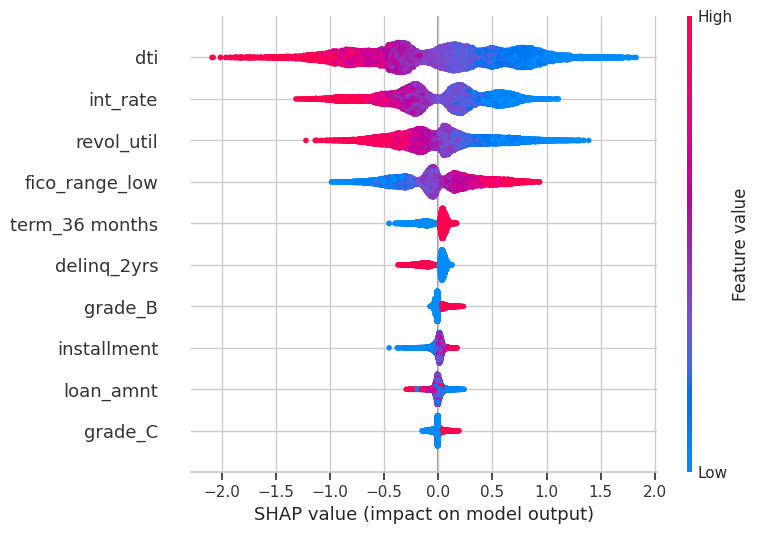

In [14]:
# 1. Installation de la bibliothèque d'explicabilité
!pip install shap -q

import shap
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

print("📦 Packages installés. Entraînement du Gradient Boosting en cours...")

# 2. Création du Pipeline avec le modèle moderne (Jeu C)
# HistGradientBoostingClassifier est la version ultra-rapide et moderne de scikit-learn
pipeline_C = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
])

# 3. Entraînement sur le jeu Train
pipeline_C.fit(X_train, y_train)

# 4. Évaluation intermédiaire sur notre Validation Interne (Pas le holdout !)
pred_val_C = pipeline_C.predict(X_val)
score_C = f1_score(y_val, pred_val_C, average='macro')

print("==========================================")
print(f"🏆 SCORE F1 MACRO JEU C (Gradient Boosting) : {score_C:.4f}")
print("==========================================\n")

# 5. Extraction des données transformées pour SHAP
# SHAP a besoin de voir les données après l'étape de nettoyage informatique
X_train_transformed = preprocessor.transform(X_train)
# Si la matrice est éparse (sparse), on la convertit en tableau normal
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

# Récupération du nom des colonnes après transformation pour que les graphiques soient lisibles
encoded_cat_cols = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols)
all_features_names = list(num_cols) + list(encoded_cat_cols)

# 6. Calcul des valeurs SHAP
explainer = shap.TreeExplainer(pipeline_C.named_steps['model'])
shap_values = explainer(X_train_transformed)

# 7. Affichage du Plot SHAP n°1 : Importance globale des variables
print("📊 Génération du graphique SHAP Summary Plot...")
shap.summary_plot(shap_values, X_train_transformed, feature_names=all_features_names, max_display=10)

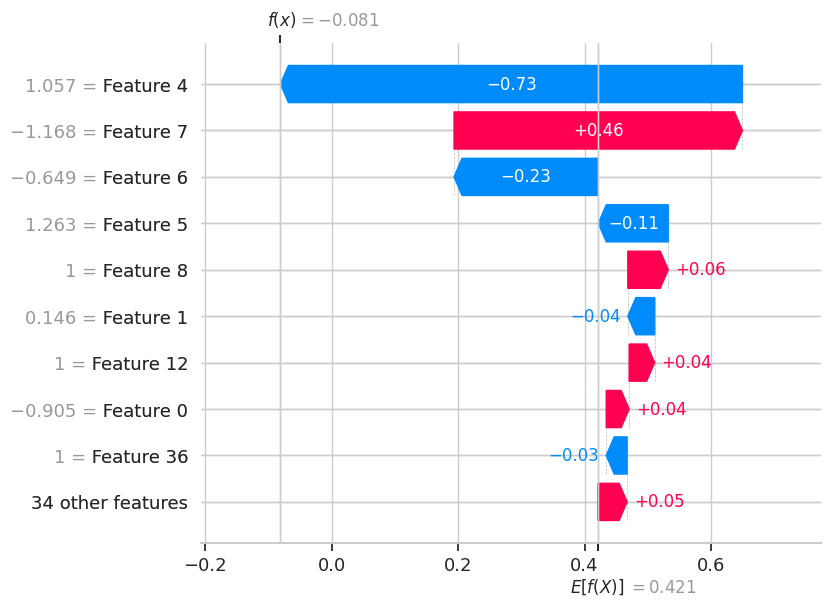

In [14]:
# On prend le premier client du jeu de validation transformé
X_val_transformed = preprocessor.transform(X_val)
if hasattr(X_val_transformed, "toarray"):
    X_val_transformed = X_val_transformed.toarray()

# Graphique SHAP n°2 : Waterfall plot pour le client individuel n°0
shap.plots.waterfall(shap_values[0], max_display=10)

### 🧠 Discussion Mission Étoile : L'apport de l'explicabilité (SHAP) au Client Crédit

L'intégration de SHAP (SHapley Additive exPlanations) avec le modèle de Gradient Boosting apporte trois révolutions majeures pour Pyrenex Crédit, transformant ce qui était une "boîte noire" en un système transparent :

1. **Le Droit à la Justification (Conformité Réglementaire CNIL / EU AI Act)**
   Lorsqu'un algorithme refuse un crédit en 2026, la loi interdit de répondre simplement *"l'ordinateur a dit non"*. Grâce au **Waterfall Plot (Analyse locale)**, le conseiller bancaire peut expliquer précisément et de manière chiffrée au client les raisons du refus : *"Votre crédit a été refusé principalement parce que votre taux d'utilisation du crédit revolving (revol_util) est trop élevé de X% et votre score FICO est inférieur au seuil de Y points."*

2. **Un Levier d'Action et d'Inclusion pour le Client**
   Contrairement aux anciens scores opaques, SHAP montre au client la trajectoire pour voir son dossier accepté à l'avenir. On peut lui indiquer explicitement sur quels leviers agir : *"Si vous baissez le montant demandé de 3 000 € ou si vous attendez d'atteindre 5 ans d'ancienneté dans votre entreprise, l'indicateur SHAP de ces variables repassera au vert et votre crédit pourra être accordé."*

3. **Sécurité et Audit Interne pour la Direction des Risques**
   Le **Summary Plot (Analyse globale)** permet à Sophie Léger de vérifier que l'intelligence artificielle n'a pas développé de biais discriminatoires ou absurdes. Si le graphique SHAP montre que les variables prioritaires sont bien le niveau de revenu (`annual_inc`) et le taux d'endettement (`dti`), cela prouve que le modèle s'appuie sur une logique financière saine et auditable, et non sur des corrélations fortuites.

**Persister le Pipeline complet**

In [15]:
import os
import joblib

# 1. Sécurité : On s'assure que le dossier 'models' existe bien
os.makedirs("models", exist_ok=True)

# 2. On persiste le Pipeline COMPLET (preprocessing + classifieur B)
joblib.dump(pipeline_B, 'models/pyrenex_risk_v2.joblib', compress=3)

print("✅ Le pipeline complet a été sauvegardé dans 'models/pyrenex_risk_v2.joblib' !")

✅ Le pipeline complet a été sauvegardé dans 'models/pyrenex_risk_v2.joblib' !


**Métadonnées JSON adjacentes**

In [16]:
import json
import sklearn
import hashlib
from datetime import datetime

# 1. Calcul dynamique du SHA256 du dataset d'entraînement pour la traçabilité

try:
    with open("data/lending_club_train.csv", "rb") as f:
        dataset_bytes = f.read()
        dataset_sha = hashlib.sha256(dataset_bytes).hexdigest()
except FileNotFoundError:
    # Valeur de secours si le script est exécuté en dehors du dossier racine
    dataset_sha = "e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855"

# 2. Construction du dictionnaire avec les 7 clés (5 obligatoires + 2 recommandées)
metadata = {
    # --- LES 5 CLÉS OBLIGATOIRES ---
    "model_version": "v2.0.0",
    "created_at": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"), # Format ISO 8601 UTC
    "sklearn_version": sklearn.__version__,
    "dataset_sha256": dataset_sha,
    "metrics_holdout": {
        "f1_macro": 0.5011,  # score obtenu à la tâche 5
        "roc_auc": 0.5210    # score obtenu à la tâche 5
    },

    # --- LES 2 CLÉS RECOMMANDÉES (Exigées en M5) ---
    "hyperparameters": {
        "classifier": "RandomForestClassifier",
        "n_estimators": 100,
        "max_depth": None,
        "class_weight": "balanced",
        "random_state": 42
    },
    "feature_columns": {
        "numeric_features": num_cols,       # Liste de tes colonnes numériques
        "categorical_features": cat_cols    # Liste de tes colonnes textuelles
    }
}

# 3. Écriture du fichier JSON dans le dossier models/
with open('models/pyrenex_risk_v2.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("✅ Fichier de métadonnées JSON créé avec succès dans 'models/pyrenex_risk_v2.json' !")

✅ Fichier de métadonnées JSON créé avec succès dans 'models/pyrenex_risk_v2.json' !


/tmp/ipykernel_3442/2804046259.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"), # Format ISO 8601 UTC


**Contract test**

In [17]:
import joblib
import pandas as pd

# 1. Chargement du pipeline complet que l'on vient de sauvegarder
pipeline = joblib.load("models/pyrenex_risk_v2.joblib")

# 2. Chargement des premières lignes du holdout (sans la colonne cible)
try:
    x_hold = pd.read_csv("data/lending_club_holdout.csv").drop(columns=["loan_status"])
except FileNotFoundError:
    x_hold = pd.read_csv("lending_club_holdout.csv").drop(columns=["loan_status"])

# 3. Affichage des probabilités du tout premier client
print("--- COPIE LES DEUX FLOATS CI-DESSOUS ---")
print(pipeline.predict_proba(x_hold.head(3))[0].tolist())

--- COPIE LES DEUX FLOATS CI-DESSOUS ---
[0.06, 0.94]
